# Memory Experiment — PQRM Code

Punctured Quantum Reed-Muller codes. Parameter (rx, rz, m).  
Supported (rx, rz, m): [(1, 2, 4), (1, 3, 5), (1, 4, 6)]. All reduced to weight-4 Z-stabilizers. High-weight X-stabilizers.  
Covers: RM generator matrix, patch construction, hypercube encoding, and memory experiment: Z-stabilizer measurement + X-stabilizer post-select.

In [1]:
import sys
from pathlib import Path
import numpy as np

ROOT = Path("../..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import stim
from lightstim.ir.builder import CircuitBuilder
from lightstim.ir.tracker import SyndromeTracker
from lightstim.ir.qec_system import QECSystem
from lightstim.noise.config import NoiseConfig
from lightstim.qec_code.PQRM import PQRMPatch, PQRMLogicalOpSet, PQRMExtractionBlock
from lightstim.qec_code.PQRM.pqrm_patch import RM_generator_matrix, LOG_PQRM_LEN_DICT

In [2]:
p = 1e-3
noise_params = NoiseConfig(p_idle=p, p_1q=p, p_2q=p, p_meas=p, p_reset=p)

## 1. RM Generator Matrix

For more detailed explanations, please see lightstim/qec_code/PQRM/pqrm_patch.py.

In [3]:
r, m = 1, 4
G, _ = RM_generator_matrix(r=r, m=m, variation="shortened")
print(f"RM({r},{m}) shortened: shape {G.shape}")
print(G)

RM(1,4) shortened: shape (4, 15)
[[1 0 1 0 1 0 1 0 1 0 1 0 1 0 1]
 [0 1 1 0 0 1 1 0 0 1 1 0 0 1 1]
 [0 0 0 1 1 1 1 0 0 0 0 1 1 1 1]
 [0 0 0 0 0 0 0 1 1 1 1 1 1 1 1]]


## 2. PQRMPatch

In [4]:
rx, rz, m = 1, 2, 4 # (rx, rz, m) = (1, 2, 4) or (1, 3, 5) or (1, 4, 6)
patch = PQRMPatch(rx=rx, rz=rz, m=m, punctured=True, shift=(0, 0))
info = patch.get_info()
for k, v in info.items():
    if k not in ("stabilizers", "logical_ops", "index_map", "qubit_coords", "coord_to_index"):
        print(f"  {k}: {v}")

z_stabs = [s for s in patch.stabilizers if s["type"] == "Z"]
x_stabs = [s for s in patch.stabilizers if s["type"] == "X"]
print(f"\nZ stabilizers (measured): {len(z_stabs)}")
print(f"X stabilizers (post-select): {len(x_stabs)}")

  code_name: PQRMPatch
  num_qubits: 25
  num_stabilizers: 14
  params: {'rx': 1, 'rz': 2, 'm': 4, 'punctured': True, 'shift': (0, 0)}
  is_transposed: False
  rotation_angle: 0.0
  rx: 1
  rz: 2
  m: 4
  punctured: True
  x_range: 4
  y_range: 4
  num_data_qubits: 15
  num_x_syndromes: 0
  num_z_syndromes: 10
  data_coords: [(0.0, 2), (2, 0.0), (2, 2), (0.0, 4), (0.0, 6), (2, 4), (2, 6), (4, 0.0), (4, 2), (6, 0.0), (6, 2), (4, 4), (4, 6), (6, 4), (6, 6)]
  syndrome_coords_z: [(3, 1), (5, 1), (1, 3), (3, 3), (5, 3), (7, 3), (1, 5), (3, 5), (5, 5), (3, 7)]
  syndrome_coords_x: []
  syndrome_coords: [(3, 1), (5, 1), (1, 3), (3, 3), (5, 3), (7, 3), (1, 5), (3, 5), (5, 5), (3, 7)]
  num_logicals: 1

Z stabilizers (measured): 10
X stabilizers (post-select): 4


## 3. Hypercube Encoding Circuit

In [5]:
def build_encoding_circuit(patch, target_state="Z"):
    system = QECSystem()
    system.add_patch(patch, name="pqrm")
    tracker = SyndromeTracker(num_qubits=system.num_qubits, expected_num_logicals=system.num_logicals)
    builder = CircuitBuilder(tracker=tracker, system_config=system, if_detector=False)
    builder.write_coordinates()
    op_set = PQRMLogicalOpSet()
    op_set.hypercube_encode(builder, patch, target_state=target_state, patch_name="pqrm")
    return builder.circuit, system

In [6]:
rx, rz, m = 1, 2, 4 # (rx, rz, m) = (1, 2, 4) or (1, 3, 5) or (1, 4, 6)
target_state = "Y" # "Z" or "X" or "Y"
patch = PQRMPatch(rx=rx, rz=rz, m=m, punctured=True, shift=(0, 0))
encode_circuit, system = build_encoding_circuit(patch, target_state)
print(f"Encoding circuit: {encode_circuit.num_qubits} qubits")
# encode_circuit.diagram("detslice-with-ops-svg")

Encoding circuit: 25 qubits


In [7]:
def build_pqrm_memory_circuit(patch, basis="Z", rounds=2, noise_params=None, noise_model="circuit_level"):
    system = QECSystem()
    system.add_patch(patch, name="pqrm")
    tracker = SyndromeTracker(num_qubits=system.num_qubits, expected_num_logicals=system.num_logicals)
    builder = CircuitBuilder(tracker=tracker, system_config=system, if_detector=True)
    builder.write_coordinates()
    op_set = PQRMLogicalOpSet()
    op_set.hypercube_encode(builder, patch, target_state=basis, patch_name="pqrm")
    builder.stabilizer_canonicalization()
    se_block = PQRMExtractionBlock(system)
    builder.apply_syndrome_extraction(circuit_chunk=se_block.circuit, rounds=rounds)
    data_indices = sorted(system.data_indices)
    builder.apply_data_readout(final_measurements={q: basis for q in data_indices})
    if noise_params is not None:
        return builder.build_noisy_circuit(noise_params=noise_params, noise_model=noise_model)
    return builder.circuit

In [8]:
# Test combinations
rx, rz, m = 1, 2, 4 # (rx, rz, m) = (1, 2, 4) or (1, 3, 5) or (1, 4, 6)
basis = "Y" # "Z" or "X" or "Y"
patch = PQRMPatch(rx=rx, rz=rz, m=m, punctured=True, shift=(0, 0))
circ = build_pqrm_memory_circuit(patch, basis=basis, rounds=2, noise_params=noise_params)
print(f"PQRM({rx},{rz},{m}) {basis}-basis: {circ.num_qubits} qubits, {circ.num_detectors} detectors")

PQRM(1,2,4) Y-basis: 25 qubits, 24 detectors


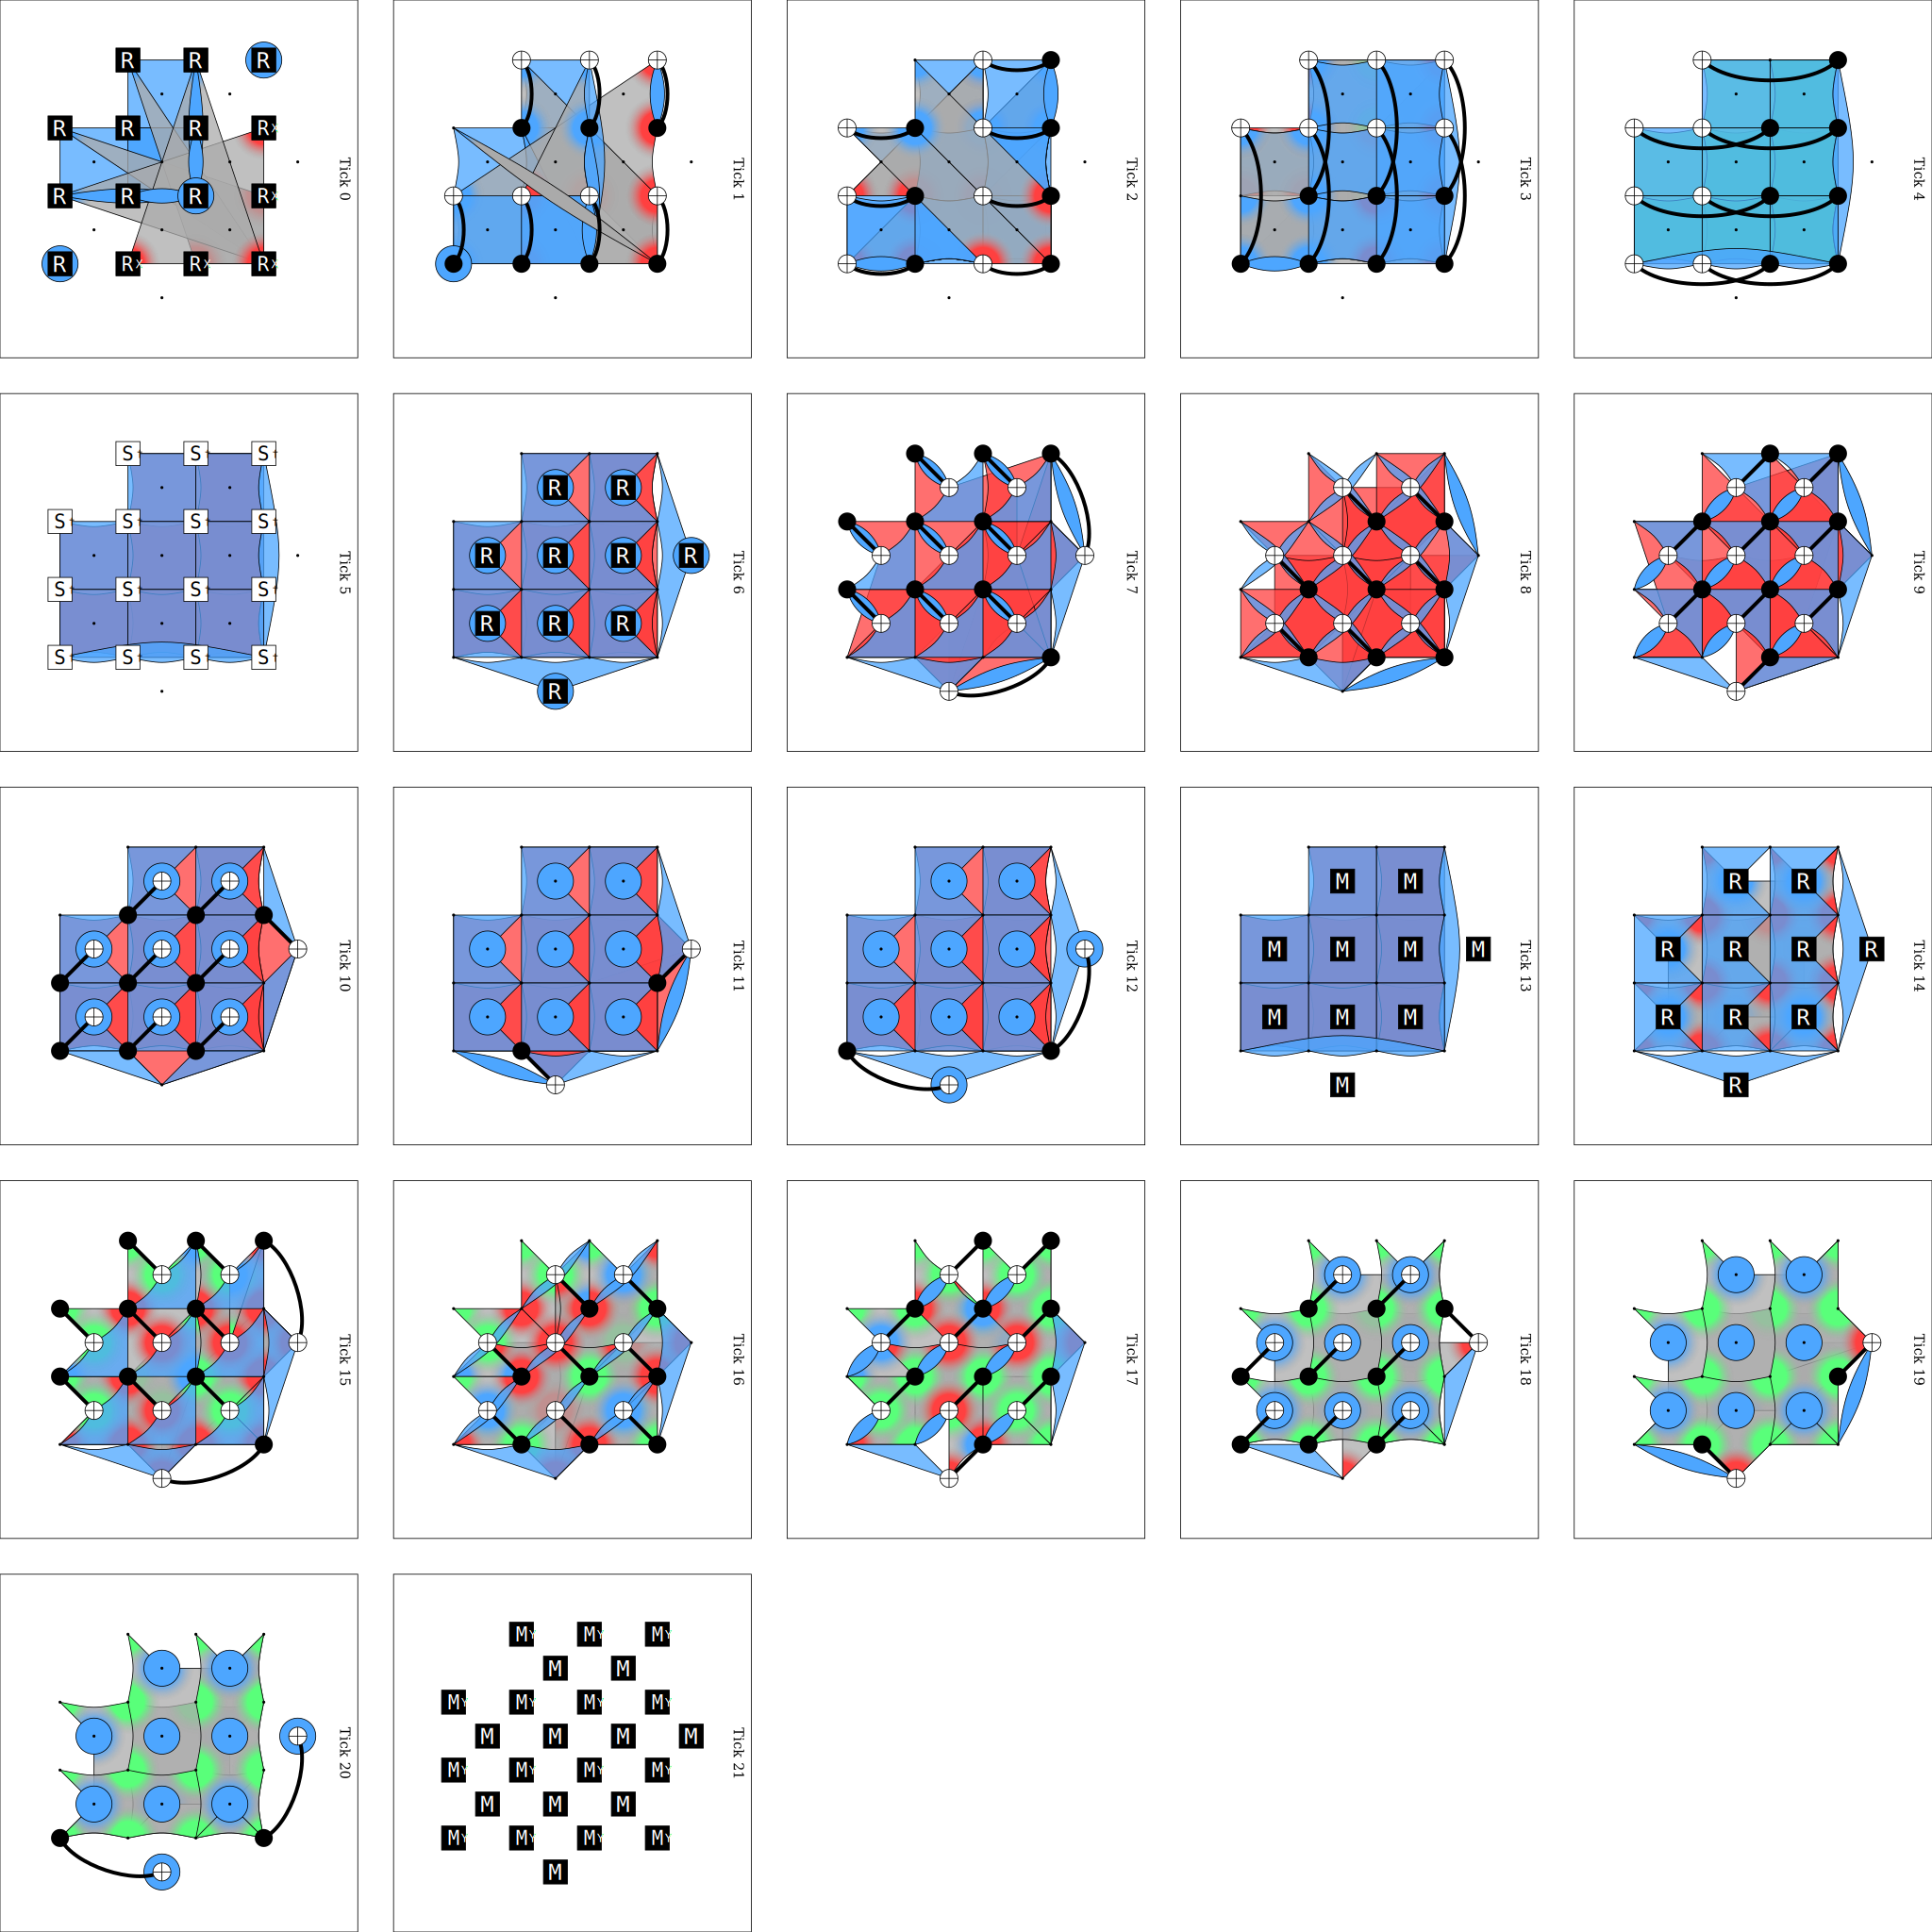

In [9]:
circ.without_noise().diagram("detslice-with-ops-svg")
# circ.without_noise().diagram("detslice-with-ops-svg", filter_coords=["L0"])

In [10]:
# Parameter sweep
for params in [(1, 2, 4), (1, 3, 5), (1, 4, 6)]:
    patch = PQRMPatch(rx=params[0], rz=params[1], m=params[2], punctured=True, shift=(0, 0))
    for basis in ["Z", "X", "Y"]:
        circ = build_pqrm_memory_circuit(patch, basis=basis, rounds=2, noise_params=noise_params)
        print(f"PQRM{params} {basis}-basis: {circ.num_qubits} qubits, {circ.num_detectors} detectors")

PQRM(1, 2, 4) Z-basis: 25 qubits, 30 detectors
PQRM(1, 2, 4) X-basis: 25 qubits, 24 detectors
PQRM(1, 2, 4) Y-basis: 25 qubits, 24 detectors
PQRM(1, 3, 5) Z-basis: 56 qubits, 75 detectors
PQRM(1, 3, 5) X-basis: 56 qubits, 55 detectors
PQRM(1, 3, 5) Y-basis: 56 qubits, 55 detectors
PQRM(1, 4, 6) Z-basis: 119 qubits, 168 detectors
PQRM(1, 4, 6) X-basis: 119 qubits, 118 detectors
PQRM(1, 4, 6) Y-basis: 119 qubits, 118 detectors
